## Шаг 1: Активируйте GPU в вашем Colab блокноте
Таким образом, обучение и детекция будут гораздо быстрее

### Шаги:

#### 1. Нажмите **Среда выполнения** в левом верхнем углу блокнота
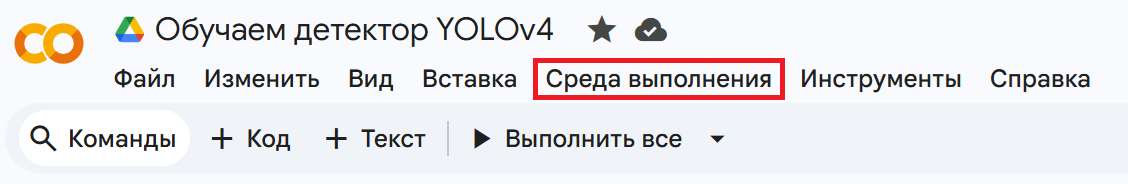
#### 2) Нажмите **Сменить среду выполнения** в появившемся меню
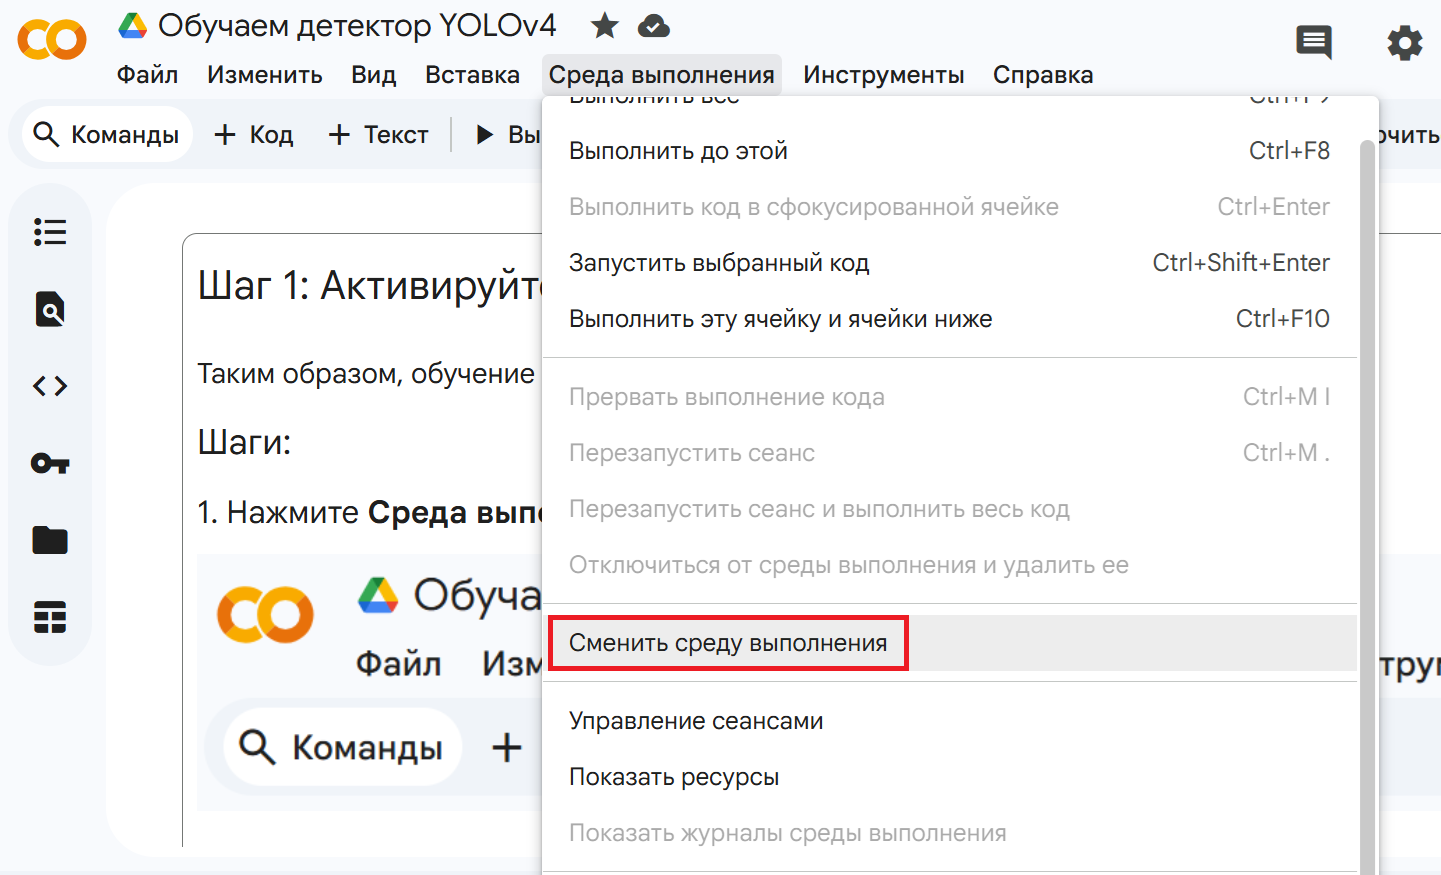
#### 3) В разделе 'Аппаратный ускоритель' выберите **Графический процессор** и нажмите кнопку **Сохранить**
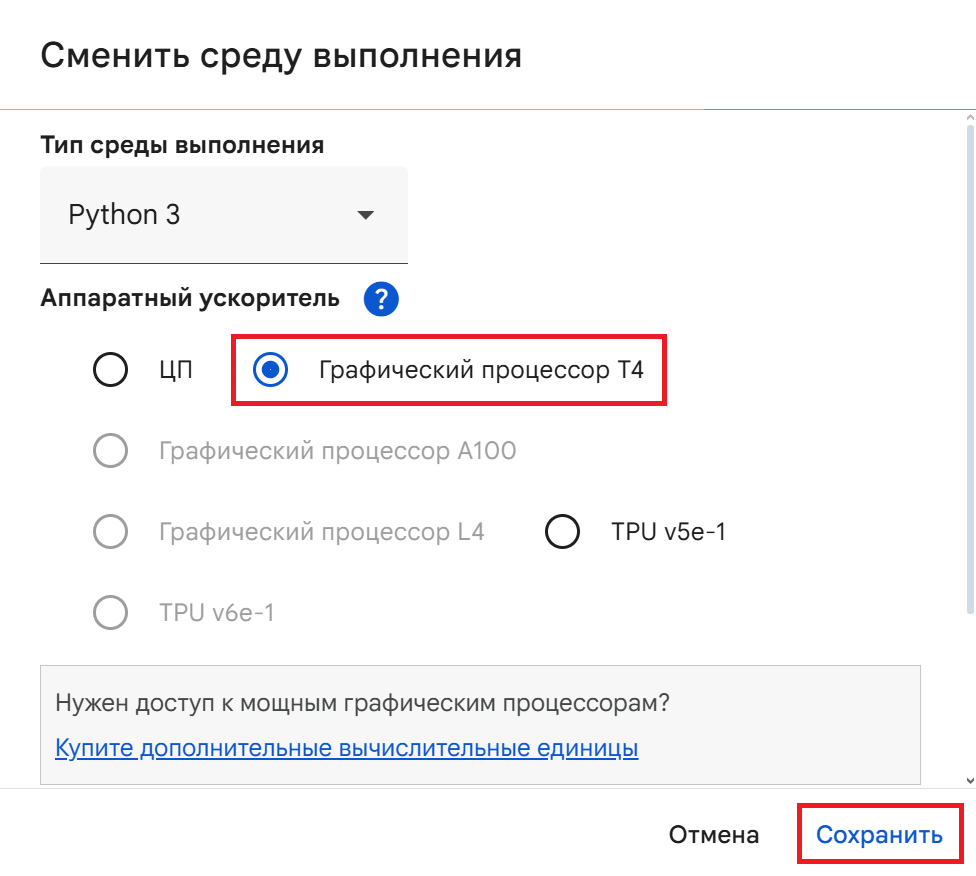
Теперь GPU должно быть включено

In [1]:
!git clone https://github.com/AlexeyAB/darknet

Cloning into 'darknet'...
remote: Enumerating objects: 15941, done.
remote: Counting objects: 100% (27/27), done.
remote: Compressing objects: 100% (23/23), done.
remote: Total 15941 (delta 13), reused 4 (delta 4), pack-reused 15914 (from 2)
Receiving objects: 100% (15941/15941), 14.52 MiB | 10.12 MiB/s, done.
Resolving deltas: 100% (10719/10719), done.


In [23]:
%cd darknet

# !sed -i 's/OPENCV=0/OPENCV=1/' Makefile
# !sed -i 's/OPENCV=1/OPENCV=0/' Makefile

!sed -i 's/GPU=0/GPU=1/' Makefile
!sed -i 's/CUDNN=0/CUDNN=1/' Makefile
!sed -i 's/CUDNN_HALF=0/CUDNN_HALF=1/' Makefile

In [24]:
# проверяем CUDA
!/usr/local/cuda/bin/nvcc --version

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2025 NVIDIA Corporation
Built on Fri_Feb_21_20:23:50_PST_2025
Cuda compilation tools, release 12.8, V12.8.93
Build cuda_12.8.r12.8/compiler.35583870_0


In [25]:
# компилируем darknet, чтобы можно было использовать darknet.exe для запуска и тренировок детекторов
!make

chmod +x *.sh
g++ -std=c++11 -std=c++11 -Iinclude/ -I3rdparty/stb/include -DGPU -I/usr/local/cuda/include/ -DCUDNN -DCUDNN_HALF -Wall -Wfatal-errors -Wno-unused-result -Wno-unknown-pragmas -fPIC -rdynamic -Ofast -DGPU -DCUDNN -I/usr/local/cudnn/include -DCUDNN_HALF -c ./src/image_opencv.cpp -o obj/image_opencv.o
g++ -std=c++11 -std=c++11 -Iinclude/ -I3rdparty/stb/include -DGPU -I/usr/local/cuda/include/ -DCUDNN -DCUDNN_HALF -Wall -Wfatal-errors -Wno-unused-result -Wno-unknown-pragmas -fPIC -rdynamic -Ofast -DGPU -DCUDNN -I/usr/local/cudnn/include -DCUDNN_HALF -c ./src/http_stream.cpp -o obj/http_stream.o
./src/http_stream.cpp: In member function ‘bool JSON_sender::write(const char*)’:
./src/http_stream.cpp:253:21: warning: unused variable ‘n’ []8;;https://gcc.gnu.org/onlinedocs/gcc/Warning-Options.html#index-Wunused-variable-Wunused-variable]8;;]
  253 |                 int n = _write(client, outputbuf, outlen);
      |                     ^
./src/http_stream.cpp: In function ‘void

## Шаг 4: Создаем вспомогательные функции


Просто удобные функции

In [5]:
from IPython.display import HTML
from base64 import b64encode
import os

# функция для отображения изображений
def show_image(path):
  import cv2
  import matplotlib.pyplot as plt
  %matplotlib inline

  image = cv2.imread(path)
  height, width = image.shape[:2]
  resized_image = cv2.resize(image,(3*width, 3*height), interpolation = cv2.INTER_CUBIC)

  fig = plt.gcf()
  fig.set_size_inches(18, 10)
  plt.axis("off")
  plt.imshow(cv2.cvtColor(resized_image, cv2.COLOR_BGR2RGB))
  plt.show()


def copy_file(file, dest):
  os.system(f'cp {file} -d {dest}')

def avi_to_mp4(avi_file, dest):
  os.system(f'ffmpeg -i {avi_file} {dest}')

def change_in_file(file, old, new):
  os.system(f"sed -i 's/{old}/{new}/' {file}")

# функция для загрузкифайлов с локальной машины в среду выполнения Colab
def upload(dst=None):
  from google.colab import files
  uploaded = files.upload()
  for name, data in uploaded.items():
    if dst:
      name = dst
    with open(name, 'wb') as f:
      f.write(data)
      print ('Файл сохранен!', name)

# функция для скачивания файловиз среды выполнения Colab на локальный копмьютер
def download(path):
  from google.colab import files
  files.download(path)

Также можно подключить ваше облачное хранилище (диск), чтобы использовать его для сохранения весов или загрузки датасета через него.

In [6]:
# Возвращаемся в корневую папку (т.к. мы сейчас в папке darknet)
%cd ..
from google.colab import drive
drive.mount('/content/gdrive')
!ln -s /content/gdrive/MyDrive/ /mydrive # это команда создаёт ссылку, которая позволяет использовать короткий путь "/mydrive" вместо длинного "/content/gdrive/MyDrive/"
#!ls /mydrive # Выводит список файлов на нашем диске
# Теперь перходим папку darknet, где будут происходить основные действия
%cd darknet

/content
Mounted at /content/gdrive
/content/darknet


# Обучаем собственный YOLOv4 детектор


Для того, чтобы обучить собственный YOLOv4 детектор вам понадобится следующее:

*   Размеченный датасет - получили из материалов задачи
*   Файл конфигурации модели (.cfg файл)
*   Файлы obj.data (хранит общую информацию о датасете) и obj.names (хранит список всех классов датасета)
*   Файл train.txt (хранит список путей до изображений, которые будут использоваться в обучении)
*   Файл test.txt (опционален, необходим для валидации при обучении)

## Шаг 1: Готовим свой датасет для обучения

Чтобы создать свой детектор объектов, вам необходим хороший датасет изображений и аннотаций к ним. Вы можете разметить собственный датасет или найти в интернете уже размеченный.

**Важно!** Аннотации к изображениям должны быть в YOLO-формате! Вот пример аннотаций в YOLO-формате:

Представим, что у нас есть изображение *(image1.jpg)* размером 200 на 100 пикселей и есть 2 объекта разных классов. Координаты центра* первого объекта на изображении (43, 52), его ширина и высота 12 и 4 пикселей сооствественно.

Координаты центра второго объекта на изображении (105, 30), его ширина и высота 20 и 13 пикселей сооствественно.

Формат записи аннотация для YOLO выглядит так:
```
<класс объекта> <X центра> <Y центра> <ширина> <высота>
```
Значения `<X центра>`, `<Y центра>`, `<ширина>`, `<высота>` относительные, т.е. принимают значения от 0 до 1. Чтобы получить относительные координаты, необходимо абсолютные разделить на размер изображения. Привычные нам <X центра>`и `<ширина>` нужно разделить на ширину изображения (в нашем случае на 200), а `<Y центра>` и `<высота>` на высоту (в нашем случае на 100).

Файл аннотаций должен находиться в папке рядом с изображений и иметь такое же имя, но с расширением '.txt'. В нашем случае файл будет выглядеть так:

***image1.txt***
```
0 0.215 0.52 0.06 0.04
1 0.525 0.3 0.1 0.13
```

### Создание и разметка собственного
Предположим, что у вас уже есть свой набор фотографий с объектами, которые вы хотите распозновать. Тогда вам необходимо воспользоваться инструментами для разметки датасетов. Вот пример 2-х таких:

#### **labelimg (простой)**
**Примечание:** Все команды вводятся в комадной строке вашего ПК.


Установка: ```pip3 install -U labelimg```

Запуск: ```labelimg```

Как пользоваться: https://github.com/tzutalin/labelImg#steps-yolo

#### **Label Studio (более продвинутый)**
Установка: ```pip3 install -U label-studio```

Запуск: ```label-studio```

Как пользоваться: https://labelstud.io/blog/Quickly-Create-Datasets-for-Training-YOLO-Object-Detection.html

In [9]:
# копируем архив с Google Drive в корневую папку блокнота
# измените путь, если архив лежит не в корне Google Drive!

# ГЛАВНОЕ название папки указать свое
!cp /mydrive/Olimp_2026/obj.zip ../

In [10]:
# распаковываем архив в папку /darknet/data/. В итоге все изображения и аннотации должны быть в /darknet/data/obj/
!unzip ../obj.zip -d data/

Archive:  ../obj.zip
  inflating: data/obj/ASJ9qg-UwH-2v7-g5Xo0T.txt  
  inflating: data/obj/ASJ9qg-UwH-2v7-g5Xo0T.jpg  
  inflating: data/obj/SO6K0l-JTu-2In-R9Tbu5.txt  
  inflating: data/obj/SO6K0l-JTu-2In-R9Tbu5.jpg  
  inflating: data/obj/JasVxP-w5j-qwk-ZS21zb.txt  
  inflating: data/obj/JasVxP-w5j-qwk-ZS21zb.jpg  
  inflating: data/obj/aNTlXE-o9m-JK7-yM1m5g.txt  
  inflating: data/obj/aNTlXE-o9m-JK7-yM1m5g.jpg  
  inflating: data/obj/lAQuk3-jx3-vju-oAisSX.txt  
  inflating: data/obj/lAQuk3-jx3-vju-oAisSX.jpg  
  inflating: data/obj/5bv3df-Ype-qv0-2tar5E.txt  
  inflating: data/obj/5bv3df-Ype-qv0-2tar5E.jpg  
  inflating: data/obj/ukzUlt-MxQ-xXU-HNlMW5.txt  
  inflating: data/obj/ukzUlt-MxQ-xXU-HNlMW5.jpg  
  inflating: data/obj/V9DbJi-mpV-WH1-MTstU4.txt  
  inflating: data/obj/V9DbJi-mpV-WH1-MTstU4.jpg  
  inflating: data/obj/E3Q2D5-qfw-PSH-yUATea.txt  
  inflating: data/obj/E3Q2D5-qfw-PSH-yUATea.jpg  
  inflating: data/obj/UkLl3G-r8o-epN-j23iSd.txt  
  inflating: data/obj/UkLl3G-

Если у вас уже есть готовые файлы `obj.names`, `obj.data`, `train.txt`, `test.txt` поместите их в папку `/darknet/data/`. Если у вас есть файл конфигурации модели (.cfg) поместите его в `/darknet/cfg/`. Если у вас нет этих файлов, не беспокойтесь, в следующем шаге мы их создадим.

## Шаг 3: Настраиваем файлы для обучения
Этот шаг покажет, как правильно настроить ваши `.cfg`, `obj.data`, `obj.names`, `train.txt` и `test.txt` файлы.

Очень важно настроить все эти файлы без ошибок. Одна незначительная ошибка может испортить обучение детектора.

### 1) Создадим `train.txt` и `test.txt`

Файл train.txt хранит в себе пути до изображений, на которых детектор будет обучаться, а файл test.txt хранит в себе пути до изображений, на которых будет происходить валидация детектора во время обучения.

Если открыть эти файлы, то в каждой строке должен быть записан путь к конкретному изображению:
```
data/obj/image1.jpg
data/obj/image2.jpg
```

Ниже представлен код который поможет создать файлы `train.txt` и `test.txt` с учётом изображений из папки `/darknet/data/obj/. Соотношение датасетов установлено 8:2, его можно изменить.

In [11]:
from random import shuffle

validation_split = 0.2  # 0.2 - это значит, что 20% от всего датасета будет использоваться для валидации (можно менять, но рекомендуется оставить таким)

files = os.listdir('data/obj/')
images = ["data/obj/"+file for file in files if file.endswith('.jpg')]
shuffle(images)

train_len = int((1-validation_split)*len(images))

train_dataset = images[:train_len]
valid_dataset = images[train_len:]

with open('data/train.txt', 'w') as f:
  txt = '\n'.join(train_dataset)
  f.write(txt)

with open('data/test.txt', 'w') as f:
  if valid_dataset:
    txt = '\n'.join(valid_dataset)
    f.write(txt)

### 2) Создадим `obj.data` и `obj.names`

Файл `obj.names` содержит в себе имена классов, каждый с новой строчки. Вот пример:
```
Elephant
Giraffe
Hippopotamus
Tiger
Zebra
```

In [12]:
# если файла с классами нет, то поместите свои классы в список ниже, и мы создадим необходимый файл
classes = ["vehicle"]
with open('data/obj.names', 'w') as f:
  f.write('\n'.join(classes))

Файл `obj.data` содержит в себе информацию о датасете и пути до файлов. Вот как он выглядит:
```
classes = <кол-во классов>
train = <файл train.txt>
valid = <файл test.txt>
names = <файл obj.names>
backup = <место, куда будут сохраняться веса во время обучения>
```

В качестве backup обычно указывается папку `backup/`, которая уже есть в папке darknet. Однако лучшим решением будет создать папку на Google Drive, в которую мы будем сохранять веса. Google Colab может отключаться, если слишком долго использовать его мощности, при этом все несохранённые файлы теряются. Файлы сохранённые на наш Google Drive не исчезнут и мы сможем продолжить обучение с того места, на котором остановились.

Блок кода ниже поможет вам создать такой файл

In [13]:
!mkdir /mydrive/Olimp_2026/backup

In [14]:
classes_amount = 1
train = 'train.txt'
valid = 'test.txt'
names = 'obj.names'
backup = '/mydrive/Olimp_2026/backup'  # '/mydrive/yolov4/backup' или 'backup/'

txt=f"""classes={classes_amount}
train=data/{train}
valid=data/{valid}
names=data/{names}
backup={backup}"""

with open('data/obj.data', 'w') as f:
  f.write(txt)

### 3) Настраиваем файл конфигурации детектора.

Файл конфигурации детектора `.cfg` определяет все основные его параметры: количество слоёв, их содержание и последовательность, настройки аугментации данных. В папке `darknet/cfg` уже находятся некоторые готовые архитектуры моделей, их там много. Нас интересует `yolov4-custom.cfg` и `yolov4-tiny-custom.cfg`. Это стандартная YOLOv4 модель и её уменьшенная версия с меньшим количеством слоёв и другими упрощенными параметрами. Вторая будет учиться гораздо быстрее, однако будет ниже точность детектирования. Для наших задач Yolov4-tiny более, чем достаточно. **Рекомендуем** сначала обучить её, а потом, если у вас не устроит точность детектирования, обучить стандартную модель!

В следующем блоке кода используется YOLOv4-tiny, но вы можете изменить параметр на False, тогда будет использоваться стандартная YOLOv4 модель.

In [15]:
yolov4_tiny = True

Теперь, когда мы выбрали архитектуру нашего детектора, нужно скопировать соотвествующий файл конфигурации из папки `darknet/cfg` и настроить детектор под ваш конректный случай, то есть изменить в нём несколько полей. Вот какие:


`width = 416`

`height = 416`

(ширину и высоту можете поменять на любые числа кратные 32. По умолчанию эти значения равны 416, иногда вы можете улучшить результат сделав значения равными например, 608, но это замедлит скорость обучения)

`max_batches = <кол-во классов> * 2000` (но не меньше 6000, поэтому, если вы тренеруете на 1, 2, или 3 классах, то ставьте 6000, однако, например, у детектора на 5 классов это значение будет max_batches=10000)

`steps = <80% от max_batches>, <90% от max_batches>` (так если max_batches = 10000, то steps = 8000, 9000)

`filters = (<кол-во классов> + 5) * 3` (так если вы обучаете детектор для 1 класса у вас будет filters = 18, однако, например, для 4 классов будет filters = 27)

`classes = <кол-во классов>` (необходимо поменять в каждом YOLO-слое)

---

Как можно отредактировать файл конфигурации?
1. Скачать файл конфигурации на свой ПК и отредактировать в любом текстовом редакторе (например, блокнот Windows).
2. Скопировать файл конфигурации на Google Drive и отредактировать его там во встроенном редакторе.
3. **Рекомендуется!** Сделать все изменения прямо в Google Colab, просто передав некоторые параметры.

*Клетки ниже помогут вам выполнить все необходимые действия, выберете один из способов*



#### 3 Способ **(Рекомендуется!)**

In [16]:
# Определяем некоторые параметры. Не забудьте изменить число классов на ваше!
#classes = 10  # Не забудьте поменять!
classes = 1
width = 416
height = 416

filters = (classes+5)*3

max_batches = classes*2000
if max_batches < 6000:
  max_batches = 6000

step1 = int(max_batches * 0.8)
step2 = int(max_batches * 0.9)

In [17]:
if yolov4_tiny:
  template_file = "cfg/yolov4-tiny-custom.cfg"
  config_file = "cfg/yolov4-tiny-obj.cfg"
  max_batches_line = "max_batches = 500200"
else:
  template_file = "cfg/yolov4-custom.cfg"
  config_file = "cfg/yolov4-obj.cfg"
  max_batches_line = "max_batches = 500500"


copy_file(template_file, config_file)  # Делаем копию файла конфигурации

# Изменяем некоторые строчки в файле с помощью нашей вспомогательной функции
change_in_file(config_file, "steps=400000,450000", f"steps={step1},{step2}")
change_in_file(config_file, "classes=80", f"classes={classes}")
change_in_file(config_file, "filters=255", f"filters={filters}")
change_in_file(config_file, max_batches_line, f"max_batches = {max_batches}")

### 3.1) Пересчёт якорей (для опытных)

Принцип работы якорей объясняется здесь: https://towardsdatascience.com/anchor-boxes-the-key-to-quality-object-detection-ddf9d612d4f9

После того как вы получили якоря, нажмите **Enter**, скопируйте веса и вставьте их в файла конфигурации в каждом YOLO слое вместо стандартных якорей (anchors).


In [26]:
if yolov4_tiny:
  !./darknet detector calc_anchors data/obj.data -num_of_clusters 6 -width 416 -height 416
else:
  !./darknet detector calc_anchors data/obj.data -num_of_clusters 9 -width 608 -height 608

 CUDA-version: 12080 (13000), cuDNN: 9.8.0, CUDNN_HALF=1, GPU count: 1  
 CUDNN_HALF=1 
 OpenCV isn't used - data augmentation will be slow 

 num_of_clusters = 6, width = 416, height = 416 
 read labels from 439 images 
 loaded 	 image: 439 	 box: 885
 all loaded. 

 calculating k-means++ ...

 iterations = 41 


counters_per_class = 885

 avg IoU = 64.84 % 

Saving anchors to the file: anchors.txt 
anchors =  30, 32,  72, 78, 167,110, 115,218, 261,216, 341,335


## Шаг 4: Скачиваем преобученные веса

На этом шаге загружаются веса сверточных слоев сети YOLOv4. Использование этих весов помогает вашему детектору объектов быть более точным и не требует слишком долгого обучения. Вам не обязательно использовать эти веса, но поверьте мне, это поможет вашей модели сходиться и быть точной намного быстрее. **ИСПОЛЬЗУЙ ЭТО!**

*Веса скачаются в папку `darknet`*


### **YOLOv4-tiny** веса

In [27]:
!wget https://github.com/AlexeyAB/darknet/releases/download/darknet_yolo_v4_pre/yolov4-tiny.conv.29

--2026-08-25 03:55:08--  https://github.com/AlexeyAB/darknet/releases/download/darknet_yolo_v4_pre/yolov4-tiny.conv.29
Resolving github.com (github.com)... 140.82.113.4
Connecting to github.com (github.com)|140.82.113.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/75388965/28807d00-3ea4-11eb-97b5-4c846ecd1d05?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-08-25T04%3A39%3A07Z&rscd=attachment%3B+filename%3Dyolov4-tiny.conv.29&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-08-25T03%3A38%3A53Z&ske=2026-08-25T04%3A39%3A07Z&sks=b&skv=2018-11-09&sig=DcXxTpDYmW8VBrXYPe1jKvJFDDm%2BpFqzLGSbG9gZwDc%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc4NzYzMTkwOCwibmJmIjoxNzg3NjMwMTA4LCJwYXRoIjoicmVsZWFzZWFzc2V

## Шаг 5: Запускаем обучение!

### Немного теории и лайфхак

Время наконец пришло! Вы добрались до момента истины! Теперь вы готовы обучить свой собственный детектор объектов YOLOv4 любым безумным классам, которые вы выбрали. Итак, выполните следующую команду. (флаг `-dont_show` останавливает отображение диаграммы, поскольку Colab блокнот не может открывать изображения на ходу (но её можно будет посмотреть после обучения), флаг `-map` отвечает за отображение средней точности на диаграмме, чтобы видеть, насколько точна ваша модель, НО! добавляйте этот флаг, только если у вас есть датасет для валидации)

```
!./darknet detector train <путь до obj.data> <путь до конфига> <путь до весов> -dont_show -map
```

**СОВЕТ.** Обучение может занять несколько часов в зависимости от того, сколько итераций (max_batches) вы выбрали в файле .cfg. Возможно, вы захотите отойти от ПК, однако облачная служба Colab отключает вас от своих виртуальных машин, если вы бездействуете слишком долго (30-90 минут).

Чтобы это избежать нажмите `CTRL + SHIFT + i`, чтобы открыть консоль браузера.

Вставьте следующий код в консоль и нажмите **Enter**.
```
function ClickConnect(){
console.log("Working");
document
  .querySelector('#top-toolbar > colab-connect-button')
  .shadowRoot.querySelector('#connect')
  .click()
}
ClickConnect();
const interval_id = setInterval(ClickConnect, 60*1000);
```

Этот скрит будет нажимать на экран каждую минуту, поэтому вас не отключат. НО НЕ ФАКТ! Google периодически меняют свои проверочные системы и это может не работать.

Чтобы отключить этот скрипт, вставьте в консоль и запустите это:
```
clearInterval(interval_id);
```
Скрипт перестанет кликать на экран

### Запускаем обучение!

Далее выберите, с какими весами хотите обучать детектор:
1. Yolov4-tiny
2. Yolov4
3. Ваши веса

Последний пункт нужен, если вы уже обучали детектор и решили почему-то остановить обучение (или Colab за вас это решил), и теперь вы хотите продолжить обучение. Это можно сделать! Просто поместите ваши веса, которые были в папке `backup` (которую вы надеюсь указали в Google Drive) в папку `darknet` и укажите их имя.

#### 1. YOLOv4-tiny

In [ ]:
!./darknet detector train data/obj.data cfg/yolov4-tiny-obj.cfg yolov4-tiny.conv.29 -dont_show -map

Выходные данные были обрезаны до нескольких последних строк (5000).

 (next mAP calculation at 1600 iterations) 

 Tensor Cores are disabled until the first 3000 iterations are reached.
 Last accuracy mAP@0.50 = 46.21 %, best = 50.27 % 1543/6000: loss=0.4 map=0.46 best=0.50 hours left=1.7
 1543: 0.427866, 0.454930 avg loss, 0.002610 rate, 1.806413 seconds, 98752 images, 1.666885 hours left
Loaded: 0.000071 seconds
v3 (iou loss, Normalizer: (iou: 0.07, obj: 1.00, cls: 1.00) Region 30 Avg (IOU: 0.760751), count: 60, class_loss = 0.388242, iou_loss = 0.095001, total_loss = 0.483242 
v3 (iou loss, Normalizer: (iou: 0.07, obj: 1.00, cls: 1.00) Region 37 Avg (IOU: 0.659451), count: 50, class_loss = 0.325988, iou_loss = 0.896577, total_loss = 1.222565 
 total_bbox = 182145, rewritten_bbox = 0.624777 % 

 (next mAP calculation at 1600 iterations) 

 Tensor Cores are disabled until the first 3000 iterations are reached.
 Last accuracy mAP@0.50 = 46.21 %, best = 50.27 % 1544/6000: loss=0.4 map=

#### 3. Ваши веса

In [ ]:
# Не забудьте поменять имя весов
!./darknet detector train data/obj.data cfg/yolov4-obj-tiny.cfg <укажите имя весов!> -dont_show -map

### Проверка точности **лучшей** модели на валидационном датасете

In [ ]:
# не забудьте поменять файл конфигурации и расположение весов, если они отличаются
!./darknet detector map data/obj.data cfg/yolov4-tiny-obj.cfg /mydrive/yolov4/backup/yolov4-obj-tiny_best.weights

### Проверка точности **последней** модели на валидационном датасете

In [ ]:
# не забудьте поменять файл конфигурации и расположение весов, если они отличаются
!./darknet detector map data/obj.data cfg/yolov4-tiny-obj.cfg /mydrive/yolov4/backup/yolov4-tiny-obj_last.weights

## Шаг 7: Запускаем ваш новый обученный детектор!

Вы это сделали! Теперь у вас есть собственный детектор! Время протестировать и повеселиться!

Но для начала необходимо немного поменять файл конфигурации, чтобы он использовался для тестирования, а не обучения!

In [ ]:
if yolov4_tiny:
  config_file = "cfg/yolov4-tiny-obj.cfg"
  test_config_file = "cfg/yolov4-tiny-obj-test.cfg"
  batch_line = "batch=64"
  subdivisions_line = "subdivisions=1"
else:
  config_file = "cfg/yolov4-obj.cfg"
  test_config_file = "cfg/yolov4-obj-test.cfg"
  batch_line = "batch=64"
  subdivisions_line = "subdivisions=16"

copy_file(config_file, test_config_file)

change_in_file(test_config_file, batch_line, "batch=1")
change_in_file(test_config_file, subdivisions_line, "subdivisions=1")

In [ ]:
# Измените путь до конфига и весов, если они отличаются! Также можете поменять путь до картинки, чтобы детектировать объекты на своей
# флаг thresh устанавливает точность детектирования при которой объект отобразится на изображении
!./darknet detector test data/obj.data cfg/yolov4-tiny-obj.cfg mydrive/yolov4/backup/yolov4-tiny-obj_last.weights data/person.jpg -thresh 0.3
show_image('predictions.jpg')